In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from urllib.parse import quote_plus

# Connection settings
username = "root"
password = quote_plus("Rajesh@1983")   # safely encodes the @ symbol
host = "localhost"
port = 3306
database = "retail_analytics"

# Create connection engine
engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Quick test
test_query = "SELECT COUNT(*) AS row_count FROM clean_transactions;"
test_df = pd.read_sql(test_query, engine)
print(test_df)

   row_count
0     805531


In [2]:
!pip install pymysql sqlalchemy

  Using cached pymysql-1.2.0-py3-none-any.whl.metadata (4.3 kB)
Using cached pymysql-1.2.0-py3-none-any.whl (45 kB)


In [4]:
query = """
SELECT 
    invoice_no,
    stock_code,
    description,
    quantity,
    invoice_date,
    unit_price,
    customer_id,
    country,
    revenue
FROM clean_transactions;
"""

df = pd.read_sql(query, engine)

print(f"Shape: {df.shape}")
print(df.dtypes)
df.head()

Shape: (805531, 9)
invoice_no              object
stock_code              object
description             object
quantity                 int64
invoice_date    datetime64[ns]
unit_price             float64
customer_id              int64
country                 object
revenue                float64
dtype: object


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [5]:
# Snapshot date = 1 day after the most recent transaction in the dataset
snapshot_date = df["invoice_date"].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date}")

rfm = df.groupby("customer_id").agg(
    recency=("invoice_date", lambda x: (snapshot_date - x.max()).days),
    frequency=("invoice_no", "nunique"),
    monetary=("revenue", "sum")
).reset_index()

print(f"Number of unique customers: {rfm.shape[0]}")
rfm.describe()

Snapshot date: 2011-12-10 12:50:00
Number of unique customers: 5878


,customer_id,recency,frequency,monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.331916,6.289384,3018.616734
std,1715.572666,209.338707,13.009406,14737.731038
min,12346.000000,1.000000,1.000000,2.950000
25%,13833.250000,26.000000,1.000000,348.762500
50%,15314.500000,96.000000,3.000000,898.915000
75%,16797.750000,380.000000,7.000000,2307.090000
max,18287.000000,739.000000,398.000000,608821.650000


In [6]:
# Recency: lower days = better = higher score (so we reverse the quantile labels)
rfm["r_score"] = pd.qcut(rfm["recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency: higher = better. Use rank first to handle duplicate values cleanly
rfm["f_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

# Monetary: higher = better
rfm["m_score"] = pd.qcut(rfm["monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

# Combine into a single RFM code and total score
rfm["rfm_score"] = rfm["r_score"].astype(str) + rfm["f_score"].astype(str) + rfm["m_score"].astype(str)
rfm["rfm_total"] = rfm[["r_score", "f_score", "m_score"]].sum(axis=1)

rfm.head(10)

,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,rfm_total
0,12346,326,12,77556.46,2,5,5,255,12
1,12347,2,8,5633.32,5,4,5,545,14
2,12348,75,5,2019.40,3,4,4,344,11
3,12349,19,4,4428.69,5,3,5,535,13
4,12350,310,1,334.40,2,1,2,212,5
5,12351,375,1,300.93,2,1,2,212,5
6,12352,36,10,2849.84,4,5,4,454,13
7,12353,204,2,406.76,2,2,2,222,6
8,12354,232,1,1079.40,2,1,3,213,6
9,12355,214,2,947.61,2,2,3,223,7


In [7]:
def segment_customer(row):
    r, f, m = row["r_score"], row["f_score"], row["m_score"]
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 3:
        return "Loyal Customers"
    elif r >= 4 and f <= 2:
        return "New Customers"
    elif r <= 2 and f >= 4:
        return "At Risk"
    elif r <= 2 and f <= 2 and m <= 2:
        return "Lost"
    elif r >= 3 and f <= 2 and m <= 2:
        return "Promising"
    else:
        return "Needs Attention"

rfm["segment"] = rfm.apply(segment_customer, axis=1)

# Summary of customers and revenue per segment
segment_summary = rfm.groupby("segment").agg(
    num_customers=("customer_id", "count"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    total_revenue=("monetary", "sum")
).sort_values("total_revenue", ascending=False)

segment_summary["pct_of_customers"] = (
    segment_summary["num_customers"] / segment_summary["num_customers"].sum() * 100
).round(1)
segment_summary["pct_of_revenue"] = (
    segment_summary["total_revenue"] / segment_summary["total_revenue"].sum() * 100
).round(1)

segment_summary

,num_customers,avg_recency,avg_frequency,avg_monetary,total_revenue,pct_of_customers,pct_of_revenue
segment,,,,,,,
Champions,1300,19.967692,17.089231,9329.319662,12128115.56,22.1,68.4
Loyal Customers,1403,71.389879,5.419102,1934.398247,2713960.74,23.9,15.3
At Risk,353,344.212465,7.572238,3190.455807,1126230.90,6.0,6.3
Needs Attention,824,359.899272,2.389563,1179.197573,971658.80,14.0,5.5
New Customers,443,28.106095,1.460497,890.832077,394638.61,7.5,2.2
Lost,1275,467.789804,1.186667,256.975098,327643.25,21.7,1.8
Promising,280,108.442857,1.242857,289.933214,81181.30,4.8,0.5


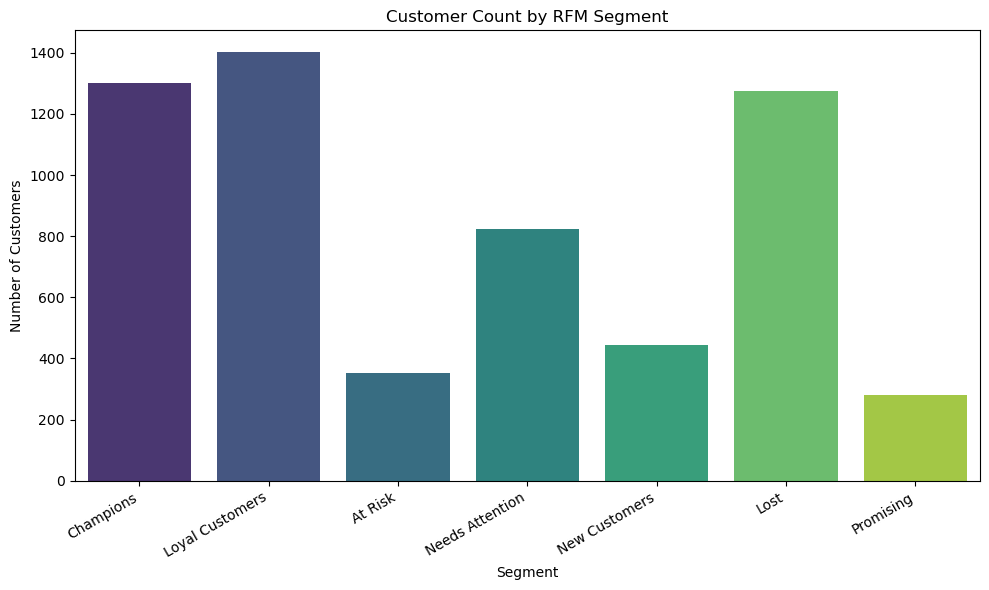

Saved chart: rfm_summary.png


In [8]:
plt.figure(figsize=(10, 6))
segment_order = segment_summary.index.tolist()
sns.barplot(
    x=segment_summary.index,
    y=segment_summary["num_customers"],
    hue=segment_summary.index,
    order=segment_order,
    palette="viridis",
    legend=False
)
plt.title("Customer Count by RFM Segment")
plt.ylabel("Number of Customers")
plt.xlabel("Segment")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("rfm_summary.png", dpi=150)
plt.show()
print("Saved chart: rfm_summary.png")

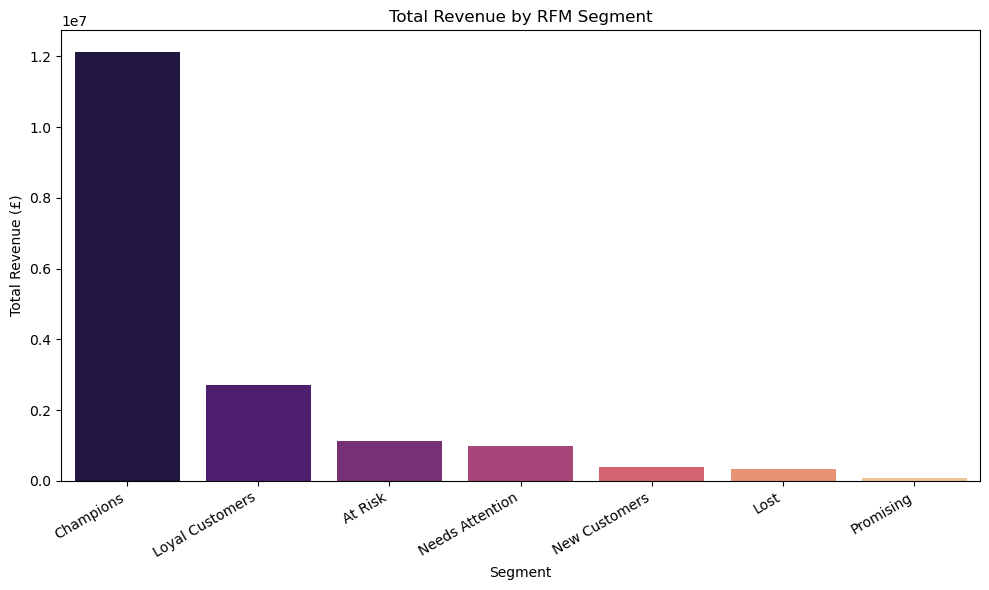

Saved chart: rfm_revenue_by_segment.png


In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=segment_summary.index,
    y=segment_summary["total_revenue"],
    hue=segment_summary.index,
    order=segment_order,
    palette="magma",
    legend=False
)
plt.title("Total Revenue by RFM Segment")
plt.ylabel("Total Revenue (£)")
plt.xlabel("Segment")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("rfm_revenue_by_segment.png", dpi=150)
plt.show()
print("Saved chart: rfm_revenue_by_segment.png")

In [10]:
# Get each customer's most common country (in case they ordered from multiple)
customer_country = df.groupby("customer_id")["country"].agg(lambda x: x.mode()[0]).reset_index()

rfm_final = rfm.merge(customer_country, on="customer_id", how="left")

# Export RFM segments — feed this into Power BI
rfm_final.to_csv("rfm_segments.csv", index=False)
print(f"Saved: rfm_segments.csv ({rfm_final.shape[0]} rows)")

# Export cleaned transaction-level data — feed this into Power BI too
df.to_csv("clean_transactions.csv", index=False)
print(f"Saved: clean_transactions.csv ({df.shape[0]} rows)")

print("\nBoth files saved in your project folder:")
print("  - rfm_segments.csv       -> customer-level RFM segments")
print("  - clean_transactions.csv -> transaction-level detail")
print("\nNext: open Power BI Desktop and import both CSVs.")

Saved: rfm_segments.csv (5878 rows)
Saved: clean_transactions.csv (805531 rows)

Both files saved in your project folder:
  - rfm_segments.csv       -> customer-level RFM segments
  - clean_transactions.csv -> transaction-level detail

Next: open Power BI Desktop and import both CSVs.


In [11]:
top_segment = segment_summary.sort_values("total_revenue", ascending=False).index[0]
at_risk_or_lost = segment_summary[segment_summary.index.isin(["At Risk", "Lost"])]

print("=== KEY INSIGHTS ===")
print(f"Total customers analyzed: {rfm_final.shape[0]:,}")
print(f"Total revenue: £{rfm_final['monetary'].sum():,.2f}")
print(f"\nTop revenue-driving segment: {top_segment}")
print(f"  -> {segment_summary.loc[top_segment, 'num_customers']:.0f} customers "
      f"({segment_summary.loc[top_segment, 'pct_of_customers']}% of customers) "
      f"generate {segment_summary.loc[top_segment, 'pct_of_revenue']}% of revenue")

if not at_risk_or_lost.empty:
    at_risk_customers = at_risk_or_lost["num_customers"].sum()
    at_risk_revenue = at_risk_or_lost["total_revenue"].sum()
    print(f"\nAt Risk / Lost customers: {at_risk_customers:.0f} "
          f"representing £{at_risk_revenue:,.2f} in historical revenue")

=== KEY INSIGHTS ===
Total customers analyzed: 5,878
Total revenue: £17,743,429.16

Top revenue-driving segment: Champions
  -> 1300 customers (22.1% of customers) generate 68.4% of revenue

At Risk / Lost customers: 1628 representing £1,453,874.15 in historical revenue


In [12]:
import os
print(os.getcwd())

C:\Users\vinjam rajesh


In [13]:
project_folder = r"C:\Users\vinjam rajesh\Desktop\Projects Analytics\retail-analytics-project"

rfm_final.to_csv(f"{project_folder}\\rfm_segments.csv", index=False)
df.to_csv(f"{project_folder}\\clean_transactions.csv", index=False)

print("Files saved to:", project_folder)

Files saved to: C:\Users\vinjam rajesh\Desktop\Projects Analytics\retail-analytics-project
